En este notebook se va a realizar el cambio de nombres de columnas, la obtención de la mediciónd de las elevaciones del Sol para 2024 y añadri la columna de año para 2024 para que ambos datasets tengan las mismas columnas.

Estos datasets transformados serán guardados en la carpeta data/interim para su uso en posteriores análisis

In [155]:
# importar datasets
import pandas as pd

df_2023 = pd.read_excel("../data/raw/datos_2023.xlsx")
df_2024 = pd.read_excel("../data/raw/datos_2024.xlsx")
df_alturas_2023 = pd.read_excel("../data/raw/alturas_2023.xlsx")

Comenzamos con los datos de 2023

In [156]:
df_2023.columns

Index(['Ano', 'Mes', 'Dia', 'Hora', 'Minuto', 'Fecha', 'GHI', 'DNI', 'DHI',
       'Temperatura [°C]', 'Velocidad del viento [m/s]',
       'Direccion del viento [º]', 'Humedad Relativa [%]', 'Codigo GHI',
       'Codigo DNI', 'Codigo dHI'],
      dtype='str')

In [157]:
column_mapping= {
    "Ano": "ano",
    "Mes": "mes",
    "Dia": "dia",
    "Hora": "hora",
    "Minuto": "minuto",
    "Fecha": "fecha",
    "DNI": "dni",
    "GHI": "ghi",
    "DHI": "dhi",
    "Temperatura [°C]": "temperatura",
    "Velocidad del viento [m/s]": "velocidad_viento",
    "Direccion del viento [º]": "direccion_viento",
    "Humedad Relativa [%]": "humedad_relativa",
    "Codigo GHI": "codigo_ghi",
    "Codigo DNI": "codigo_dni",
    "Codigo dHI": "codigo_dhi"
}

df_2023.rename(columns=column_mapping, inplace=True)
df_2023.head()

,ano,mes,dia,hora,minuto,fecha,ghi,dni,dhi,temperatura,velocidad_viento,direccion_viento,humedad_relativa,codigo_ghi,codigo_dni,codigo_dhi
0,2023,1,1,0,0,2023-01-01 00:00:00,0.0,0.0,0.0,10.0,1.050,117.750,77.0,0,0,0
1,2023,1,1,0,1,2023-01-01 00:01:00,0.0,0.0,0.0,10.0,1.333,311.500,77.0,0,0,0
2,2023,1,1,0,2,2023-01-01 00:02:00,0.0,0.0,0.0,10.0,1.100,256.417,77.0,0,0,0
3,2023,1,1,0,3,2023-01-01 00:03:00,0.0,0.0,0.0,10.0,1.333,290.417,77.0,0,0,0
4,2023,1,1,0,4,2023-01-01 00:04:00,0.0,0.0,0.0,10.0,1.058,333.667,77.0,0,0,0


In [158]:
df_2024.rename(columns=column_mapping, inplace=True)
df_2024.insert(0, "ano", 2024)
df_2024.head()

,ano,mes,dia,hora,minuto,fecha,ghi,dni,dhi,temperatura,velocidad_viento,direccion_viento,humedad_relativa,codigo_ghi,codigo_dni,codigo_dhi
0,2024,1,1,0,0,2024-01-01 00:00:00,0.0,0.0,0.0,9.2,0.925,312.167,92.000,0,0,0
1,2024,1,1,0,1,2024-01-01 00:01:00,0.0,0.0,0.0,9.2,1.125,310.833,92.167,0,0,0
2,2024,1,1,0,2,2024-01-01 00:02:00,0.0,0.0,0.0,9.2,1.233,304.333,92.417,0,0,0
3,2024,1,1,0,3,2024-01-01 00:03:00,0.0,0.0,0.0,9.2,1.083,313.500,92.000,0,0,0
4,2024,1,1,0,4,2024-01-01 00:04:00,0.0,0.0,0.0,9.2,1.050,311.000,92.333,0,0,0


In [159]:
print("Tamaño del dataset 2023:", df_2023.shape)
print("Tamaño del dataset 2024:", df_2024.shape)


Tamaño del dataset 2023: (525600, 16)
Tamaño del dataset 2024: (527040, 16)


Se aplica una codificación cíclica mediante funciones seno y coseno a la dirección del viento, la hora del día y el mes del año. Esta transformación permite preservar la periodicidad inherente de estas variables y representar adecuadamente la proximidad entre los extremos de cada ciclo. Así, por ejemplo, las 23:00 y las 00:00, diciembre y enero, o las direcciones 359° y 0° quedan representadas como valores próximos.

In [160]:
import numpy as np

def codify_cyclic_features(df):
    """
    La función codifica la dirección del viento, la hora del día y el mes
    del año mediante transformaciones trigonométricas. Esto permite representar
    correctamente su carácter periódico, de forma que valores cercanos al inicio
    y al final de cada ciclo también queden próximos en el espacio transformado.
    """

    df['direccion_viento_sin'] = np.sin(np.radians(df['direccion_viento']))
    df['direccion_viento_cos'] = np.cos(np.radians(df['direccion_viento']))

    df["hora_sin"] = np.sin(2 * np.pi * df["hora"] / 24)
    df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)

    df["mes_sin"] = np.sin(2 * np.pi * (df["mes"] - 1) / 12)
    df["mes_cos"] = np.cos(2 * np.pi * (df["mes"] - 1) / 12)

    df.drop(columns=['direccion_viento', 'hora', 'mes'], inplace=True)
    ordered_columns = ['ano', 'mes_sin', 'mes_cos', 'dia', 'hora_sin', 'hora_cos', 'minuto', 'fecha', 'ghi', 'dni', 'dhi',
       'temperatura', 'velocidad_viento', 'humedad_relativa', 'direccion_viento_sin', 'direccion_viento_cos',
        'codigo_ghi', 'codigo_dni', 'codigo_dhi']
    df.colums = ordered_columns

    return df

df_2023 = codify_cyclic_features(df_2023)
df_2024 = codify_cyclic_features(df_2024)
df_2023.columns


C:\Users\zacar\AppData\Local\Temp\ipykernel_15204\4238484153.py:24: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.colums = ordered_columns
C:\Users\zacar\AppData\Local\Temp\ipykernel_15204\4238484153.py:24: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.colums = ordered_columns


Index(['ano', 'dia', 'minuto', 'fecha', 'ghi', 'dni', 'dhi', 'temperatura',
       'velocidad_viento', 'humedad_relativa', 'codigo_ghi', 'codigo_dni',
       'codigo_dhi', 'direccion_viento_sin', 'direccion_viento_cos',
       'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos'],
      dtype='str')

Una vez cambiado el nombre de las columnas, se guardan en formato parquet para reducir el espacio y mejorar la eficiencia

In [161]:
from pathlib import Path

INTERIM_PATH = Path("../data/interim")
INTERIM_PATH.mkdir(parents=True, exist_ok=True)

df_2023.to_parquet(INTERIM_PATH / "datos_2023_standardized.parquet", index=False)
df_2024.to_parquet(INTERIM_PATH / "datos_2024_standardized.parquet", index=False)

Pasamos ahora a generar el dataset de las elevaciones solares para ambos años. Ahora mismo solo se tienen las elevaciones del año 2023 por lo que se tendrá que generar el de 2024.

Para el caso de 2023, se cambia la columna 'altura' por 'elevacion_solar' ya que realmente mide la elevación solar en grados y no en metros.

Además, se van a extraer los datos de elevacion solar de la misma manera que se propone para 2024 para ver la similitud de los datos

In [162]:
df_alturas_2023.head()

,Fecha,Año,Mes,Dia,Hora,Min,altura
0,2023-01-01 00:00:00,2023,1.0,1,0,0,0.0
1,2023-01-01 00:01:00,2023,1.0,1,0,1,0.0
2,2023-01-01 00:02:00,2023,1.0,1,0,2,0.0
3,2023-01-01 00:03:00,2023,1.0,1,0,3,0.0
4,2023-01-01 00:04:00,2023,1.0,1,0,4,0.0


In [163]:
print("Tamaño del dataset de elevaciones de 2023:", df_alturas_2023.shape)

Tamaño del dataset de elevaciones de 2023: (525601, 7)


Ya vimos en el anterior notebook que la última medición del dataset de alturas correspondia al primer minuto de 2024, por lo que se va a a eliminar para cuadrar correctamente con el dataset de mediciones de 2023

In [164]:
df_alturas_2023.drop(axis=0, index=len(df_alturas_2023)-1, inplace=True)
df_alturas_2023.tail()

,Fecha,Año,Mes,Dia,Hora,Min,altura
525595,2023-12-31 23:55:00,2023,12.0,365,23,55,0.0
525596,2023-12-31 23:56:00,2023,12.0,365,23,56,0.0
525597,2023-12-31 23:57:00,2023,12.0,365,23,57,0.0
525598,2023-12-31 23:58:00,2023,12.0,365,23,58,0.0
525599,2023-12-31 23:59:00,2023,12.0,365,23,59,0.0


In [165]:
column_mapping.update({
    'Año': 'ano',
    'Min': 'minuto',
    'altura': 'elevacion_solar'
})

df_alturas_2023.rename(columns=column_mapping, inplace=True)
df_alturas_2023.head()

,fecha,ano,mes,dia,hora,minuto,elevacion_solar
0,2023-01-01 00:00:00,2023,1.0,1,0,0,0.0
1,2023-01-01 00:01:00,2023,1.0,1,0,1,0.0
2,2023-01-01 00:02:00,2023,1.0,1,0,2,0.0
3,2023-01-01 00:03:00,2023,1.0,1,0,3,0.0
4,2023-01-01 00:04:00,2023,1.0,1,0,4,0.0


In [166]:
from pvlib.location import Location

# Datos de la estación meteorológica de Sevilla
LATITUDE = 37.41
LONGITUDE = -6.01 # Oeste se representa con signo negativo
ALTITUDE = 12           
TIMEZONE = "Europe/Madrid"

# Crear todos los minutos de 2023 en UTC. Para ello se comienza una hora menos que la hora local de Sevilla, que es UTC+1. 
# Esto es porque el método get_solarposition() requiere que los timestamps estén en UTC.
timestamps_utc = pd.date_range(
    start="2023-01-01 00:00:00",
    end="2024-01-01 00:00:00",
    freq="1min",
    inclusive="left",
    tz="UTC"
)

station = Location(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    tz=TIMEZONE,
    altitude=ALTITUDE,
    name="Estacion_Sevilla"
)

solar_position_2023 = station.get_solarposition(
    times=timestamps_utc,
    method="nrel_numpy"
)

solar_position_2023.head()

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2023-01-01 00:00:00+00:00,164.485290,164.485290,-74.485290,-74.485290,335.934111,-3.187402
2023-01-01 00:01:00+00:00,164.564907,164.564907,-74.564907,-74.564907,336.742736,-3.187731
2023-01-01 00:02:00+00:00,164.641937,164.641937,-74.641937,-74.641937,337.558903,-3.188060
2023-01-01 00:03:00+00:00,164.716341,164.716341,-74.716341,-74.716341,338.382472,-3.188389
2023-01-01 00:04:00+00:00,164.788081,164.788081,-74.788081,-74.788081,339.213289,-3.188718


Del notebook anterior, a través del describe realizado al dataset de elevaciones solares, sabemos que los valores negativos de elevación se han cambiado por un valor de 0 ya que valores negativos suponen nocturnidad y suelen estar relacionados con irradancias nulas. 

Además, se sabe que los datos dados de 2023 vienen de la [estación meteorológica de GTER](https://estacionmeteo.us.gter.es/) cuyo sensor óptico sigue la posición visible del Sol, es decir, la posición afectada por la refracción atmosférica, lo que corresponde con la medida de apparent_elevation obtenida anteriormente ya que mide la elevación solar aparente, corregida por refracción. 

De esta manera, nos quedamos con la columna de 'apparent_elevation' pero cambiamos los valores negativos por 0 para una mejor comparación con los valores del dataset original

In [167]:
elevacion_solar_2023 = pd.DataFrame({
 "fecha": solar_position_2023.index.tz_convert(None),
 "elevacion_solar": solar_position_2023["apparent_elevation"].clip(lower=0)
}).reset_index(drop=True)

elevacion_solar_2023.head()

,fecha,elevacion_solar
0,2023-01-01 00:00:00,0.0
1,2023-01-01 00:01:00,0.0
2,2023-01-01 00:02:00,0.0
3,2023-01-01 00:03:00,0.0
4,2023-01-01 00:04:00,0.0


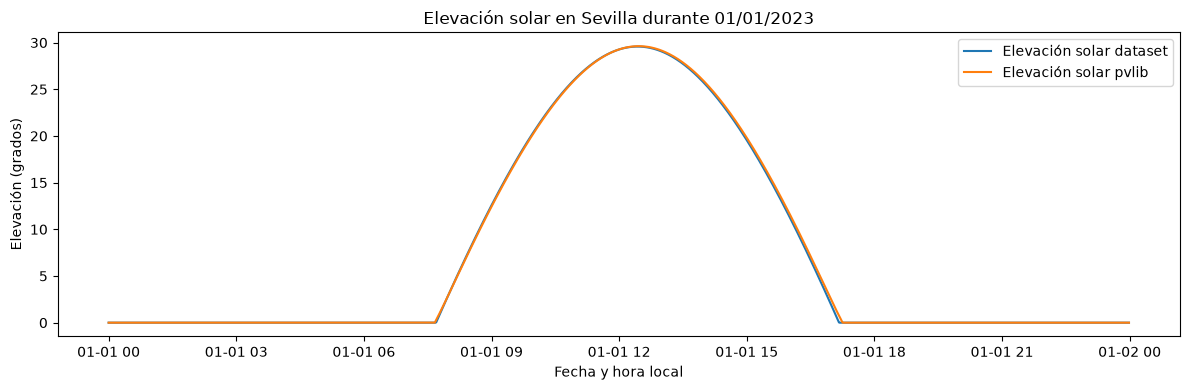

In [168]:
import matplotlib.pyplot as plt

df_2023_primero_enero = df_alturas_2023[df_alturas_2023["fecha"].dt.date == pd.to_datetime("2023-01-01").date()]
primero_enero_2023 = elevacion_solar_2023[elevacion_solar_2023["fecha"].dt.date == pd.to_datetime("2023-01-01").date()]

plt.figure(figsize=(12,4))
plt.plot(df_2023_primero_enero["fecha"], df_2023_primero_enero['elevacion_solar'], label="Elevación solar dataset")
plt.plot(primero_enero_2023["fecha"], primero_enero_2023['elevacion_solar'], label="Elevación solar pvlib")
plt.title("Elevación solar en Sevilla durante 01/01/2023")
plt.xlabel("Fecha y hora local")
plt.ylabel("Elevación (grados)")
plt.legend()
plt.tight_layout()
plt.show()

In [169]:
error_elevacion = pd.DataFrame({
    "fecha": df_alturas_2023['fecha'].dt.date,
    "error_elevacion": df_alturas_2023["elevacion_solar"].values - elevacion_solar_2023["elevacion_solar"].values
})

error_elevacion.describe().T


,count,mean,std,min,25%,50%,75%,max
error_elevacion,525600.0,-0.034959,0.137132,-0.784864,-0.070997,0.0,0.0,0.270609


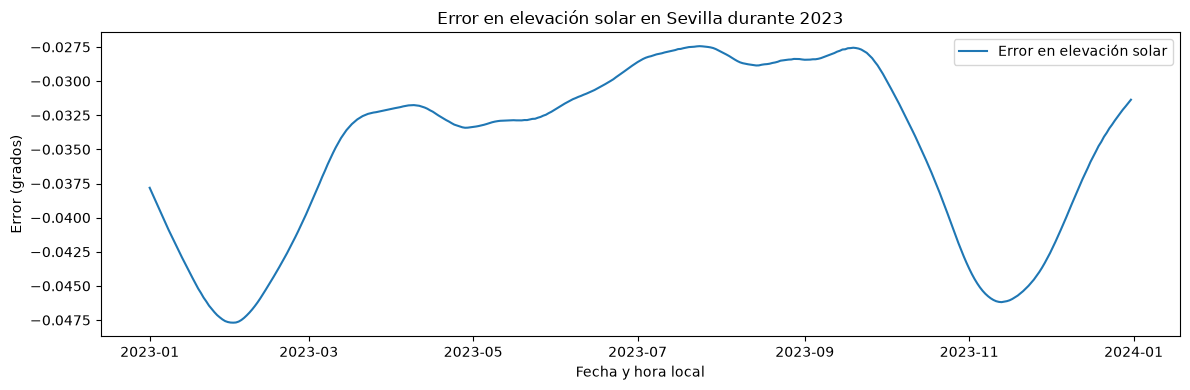

In [170]:
media_diaria_error = error_elevacion.groupby("fecha").mean()

plt.figure(figsize=(12, 4))
plt.plot(media_diaria_error.index, media_diaria_error["error_elevacion"], label="Error en elevación solar")
plt.title("Error en elevación solar en Sevilla durante 2023")
plt.xlabel("Fecha y hora local")
plt.ylabel("Error (grados)")
plt.legend()
plt.tight_layout()
plt.show()

El máximo error entre ambos valores es menor a 0.8º en términos absolutos por lo que se considera una buena librería para obtener los datos de elevación solar para 2024, al no tener otra manera de obtenerlos. 

Además, debido al gran parecido de estos dos datasets, se van a recuperar los valores negativos de elevacion solar para una posible aproximación de series temporales a la hora del las predicciones finales de la clasificación

In [171]:
import numpy as np

df_alturas_2023['elevacion_solar'] = np.where(df_alturas_2023['elevacion_solar'] == 0, solar_position_2023["apparent_elevation"].values, df_alturas_2023['elevacion_solar'])
df_alturas_2023.head()

,fecha,ano,mes,dia,hora,minuto,elevacion_solar
0,2023-01-01 00:00:00,2023,1.0,1,0,0,-74.485290
1,2023-01-01 00:01:00,2023,1.0,1,0,1,-74.564907
2,2023-01-01 00:02:00,2023,1.0,1,0,2,-74.641937
3,2023-01-01 00:03:00,2023,1.0,1,0,3,-74.716341
4,2023-01-01 00:04:00,2023,1.0,1,0,4,-74.788081


In [172]:
df_alturas_2023.to_parquet(INTERIM_PATH / "elevacion_2023_standardized.parquet", index=False)


Generamos ahora los datos para 2024

In [173]:
timestamps_utc = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2025-01-01 00:00:00",
    freq="1min",
    inclusive="left",
    tz="UTC"
)

station = Location(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    tz=TIMEZONE,
    altitude=ALTITUDE,
    name="Estacion_Sevilla"
)

solar_position_2024 = station.get_solarposition(
    times=timestamps_utc,
    method="nrel_numpy"
)

df_solar_2024 = (
    solar_position_2024[
        [
            "apparent_elevation"
        ]
    ]
    .rename_axis("timestamp_utc")
    .reset_index()
)

df_solar_2024.head()

,timestamp_utc,apparent_elevation
0,2024-01-01 00:00:00+00:00,-74.511897
1,2024-01-01 00:01:00+00:00,-74.591303
2,2024-01-01 00:02:00+00:00,-74.668118
3,2024-01-01 00:03:00+00:00,-74.742301
4,2024-01-01 00:04:00+00:00,-74.813812


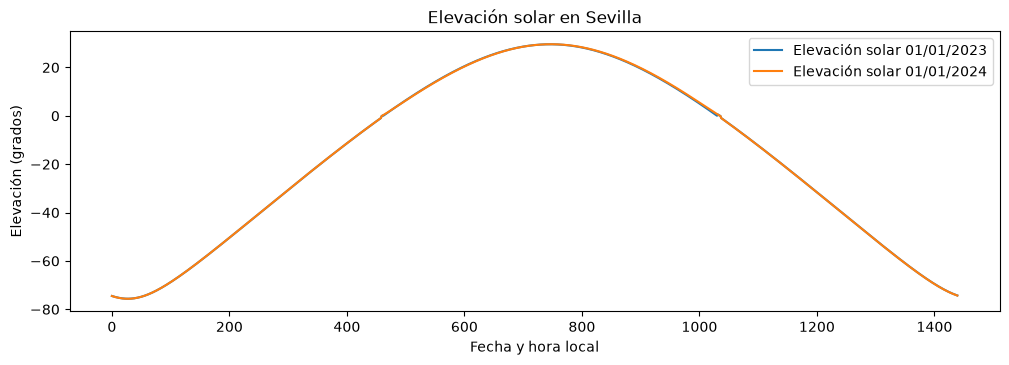

In [174]:
import matplotlib.pyplot as plt

primero_enero_2023 = df_alturas_2023[df_alturas_2023["fecha"].dt.date == pd.to_datetime("2023-01-01").date()]
primero_enero_2024 = df_solar_2024[df_solar_2024["timestamp_utc"].dt.date == pd.to_datetime("2024-01-01").date()]

plt.figure(figsize=(12, 8))
plt.subplot(2,1,1)
plt.plot(primero_enero_2023["fecha"].dt.hour * 60 + primero_enero_2023["fecha"].dt.minute, primero_enero_2023['elevacion_solar'], label="Elevación solar 01/01/2023")
plt.plot(primero_enero_2024["timestamp_utc"].dt.hour * 60 + primero_enero_2024["timestamp_utc"].dt.minute, primero_enero_2024["apparent_elevation"], label="Elevación solar 01/01/2024")
plt.title("Elevación solar en Sevilla")
plt.xlabel("Fecha y hora local")
plt.ylabel("Elevación (grados)")
plt.legend()
plt.show()


Podemos ver que para el 1 de enero de ambos años, las gráficas de elevación son prácticamente idénticas, propio de la época del año en el que se encuentran

De esta manera se procede a obtener el dataset de 2024 de alturas, obteniendo las mismas columnas que se tienen para el caso de 2023

In [175]:
df_alturas_2024 = pd.DataFrame({
    "fecha": timestamps_utc.tz_localize(None),
    "elevacion_solar": df_solar_2024["apparent_elevation"]
})

df_alturas_2024['ano'] = df_alturas_2024['fecha'].dt.year
df_alturas_2024['mes'] = df_alturas_2024['fecha'].dt.month
df_alturas_2024['dia'] = df_alturas_2024['fecha'].dt.dayofyear
df_alturas_2024['hora'] = df_alturas_2024['fecha'].dt.hour
df_alturas_2024['minuto'] = df_alturas_2024['fecha'].dt.minute

orden_columnas = df_alturas_2023.columns.tolist()
df_alturas_2024 = df_alturas_2024[orden_columnas]

df_alturas_2024.head()

,fecha,ano,mes,dia,hora,minuto,elevacion_solar
0,2024-01-01 00:00:00,2024,1,1,0,0,-74.511897
1,2024-01-01 00:01:00,2024,1,1,0,1,-74.591303
2,2024-01-01 00:02:00,2024,1,1,0,2,-74.668118
3,2024-01-01 00:03:00,2024,1,1,0,3,-74.742301
4,2024-01-01 00:04:00,2024,1,1,0,4,-74.813812


In [176]:
df_alturas_2024.info()

<class 'pandas.DataFrame'>
RangeIndex: 527040 entries, 0 to 527039
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   fecha            527040 non-null  datetime64[us]
 1   ano              527040 non-null  int32         
 2   mes              527040 non-null  int32         
 3   dia              527040 non-null  int32         
 4   hora             527040 non-null  int32         
 5   minuto           527040 non-null  int32         
 6   elevacion_solar  527040 non-null  float64       
dtypes: datetime64[us](1), float64(1), int32(5)
memory usage: 18.1 MB


In [177]:
print("Duplicados fecha:", df_alturas_2024['fecha'].duplicated().sum())
print("Dataset de alturas ordenado:", df_alturas_2024['fecha'].is_monotonic_increasing)

Duplicados fecha: 0
Dataset de alturas ordenado: True


In [178]:
df_alturas_2024.to_parquet(INTERIM_PATH / "elevacion_2024_standardized.parquet", index=False)

Ahora integramos las mediciones con las elevaciones

In [179]:
df_2023_integrated = df_2023.merge(
    df_alturas_2023[["fecha", "elevacion_solar"]],
    on="fecha",
    how="left",
    validate="one_to_one"
)

df_2024_integrated = df_2024.merge(
    df_alturas_2024[["fecha", "elevacion_solar"]],
    on="fecha",
    how="left",
    validate="one_to_one"
)

df_2023_integrated.head()

,ano,dia,minuto,fecha,ghi,dni,dhi,temperatura,velocidad_viento,humedad_relativa,codigo_ghi,codigo_dni,codigo_dhi,direccion_viento_sin,direccion_viento_cos,hora_sin,hora_cos,mes_sin,mes_cos,elevacion_solar
0,2023,1,0,2023-01-01 00:00:00,0.0,0.0,0.0,10.0,1.050,77.0,0,0,0,0.884988,-0.465615,0.0,1.0,0.0,1.0,-74.485290
1,2023,1,1,2023-01-01 00:01:00,0.0,0.0,0.0,10.0,1.333,77.0,0,0,0,-0.748956,0.662620,0.0,1.0,0.0,1.0,-74.564907
2,2023,1,2,2023-01-01 00:02:00,0.0,0.0,0.0,10.0,1.100,77.0,0,0,0,-0.972031,-0.234854,0.0,1.0,0.0,1.0,-74.641937
3,2023,1,3,2023-01-01 00:03:00,0.0,0.0,0.0,10.0,1.333,77.0,0,0,0,-0.937179,0.348850,0.0,1.0,0.0,1.0,-74.716341
4,2023,1,4,2023-01-01 00:04:00,0.0,0.0,0.0,10.0,1.058,77.0,0,0,0,-0.443587,0.896231,0.0,1.0,0.0,1.0,-74.788081


In [181]:
ordered_columns = ['ano', 'mes_sin', 'mes_cos', 'dia', 'hora_sin', 'hora_cos', 'minuto', 'fecha', 'ghi', 'dni', 'dhi', 'elevacion_solar',
        'temperatura', 'velocidad_viento', 'humedad_relativa', 'direccion_viento_sin', 'direccion_viento_cos',
        'codigo_ghi', 'codigo_dni', 'codigo_dhi']

df_2023_integrated = df_2023_integrated[ordered_columns]
df_2024_integrated = df_2024_integrated[ordered_columns]

df_2024_integrated.head()

,ano,mes_sin,mes_cos,dia,hora_sin,hora_cos,minuto,fecha,ghi,dni,dhi,elevacion_solar,temperatura,velocidad_viento,humedad_relativa,direccion_viento_sin,direccion_viento_cos,codigo_ghi,codigo_dni,codigo_dhi
0,2024,0.0,1.0,1,0.0,1.0,0,2024-01-01 00:00:00,0.0,0.0,0.0,-74.511897,9.2,0.925,92.000,-0.741191,0.671294,0,0,0
1,2024,0.0,1.0,1,0.0,1.0,1,2024-01-01 00:01:00,0.0,0.0,0.0,-74.591303,9.2,1.125,92.167,-0.756619,0.653856,0,0,0
2,2024,0.0,1.0,1,0.0,1.0,2,2024-01-01 00:02:00,0.0,0.0,0.0,-74.668118,9.2,1.233,92.417,-0.825774,0.564002,0,0,0
3,2024,0.0,1.0,1,0.0,1.0,3,2024-01-01 00:03:00,0.0,0.0,0.0,-74.742301,9.2,1.083,92.000,-0.725374,0.688355,0,0,0
4,2024,0.0,1.0,1,0.0,1.0,4,2024-01-01 00:04:00,0.0,0.0,0.0,-74.813812,9.2,1.050,92.333,-0.754710,0.656059,0,0,0


In [182]:
assert df_2023_integrated["elevacion_solar"].notna().all()
assert df_2024_integrated["elevacion_solar"].notna().all()

Y concatenamos ambos años

In [184]:
df_all = (
    pd.concat(
        [df_2023_integrated, df_2024_integrated],
        ignore_index=True
    )
    .sort_values("fecha")
    .reset_index(drop=True)
)

df_all.to_parquet(
    "../data/processed/dataset_solar_2023_2024_v1.parquet",
    index=False
)